# 🔬 مشروع الميكروسكوب الرقمي الذكي (Smart Digital Microscope)
## تطبيق الخطوات 1-7: التحليل، المعالجة المسبقة، وبناء نموذج التصنيف (EfficientNetB3)

**ملاحظة هامة:** تم تصميم هذا الكود لتطبيق أفضل الممارسات: **تجنب المعالجة المسبقة في مكانها (In-Place)**، واستخدام **مولدات البيانات (ImageDataGenerator)** لتطبيق التغييرات (Resize, Normalize, Augmentation) في الذاكرة، والعمل على صور **RGB (3 قنوات)** لزيادة دقة EfficientNetB3.


## ⚙️ الإعداد والتحميل
### الخلية 1: استيراد المكتبات وتحديد المسارات


In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# **تعديل المسار هنا إلى المسار الفعلي لمجموعة البيانات**
DATASET_PATH = "/content/drive/MyDrive/blood-cells-dataset/Naturalize 2K-PBC Dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 11


## ⚙️ الخطوة 1: استكشاف البيانات (Exploratory Data Analysis - EDA)
### الخلية 2: تحليل التوزيع العام للفئات (EDA)
**تطبيق النصيحة:** استخدام Plotly لعرض تفاعلي لتوزيع الفئات.


In [4]:
data = []
splits = ['Train', 'Test', 'Validate']

# Check if the dataset path exists
print(f"Searching for dataset at: {DATASET_PATH}")
print(f"Dataset path exists: {os.path.exists(DATASET_PATH)}")

if not os.path.exists(DATASET_PATH):
    print("Error: Dataset path not found. Please check the DATASET_PATH variable.")
else:
    for split in splits:
        split_path = os.path.join(DATASET_PATH, split)
        print(f"Checking path: {split_path} - Exists: {os.path.exists(split_path)}")
        
        if os.path.exists(split_path):
            print(f"Directories in {split}: {os.listdir(split_path)[:5]}...")  # Show first 5 items
            for cls in os.listdir(split_path):
                cls_path = os.path.join(split_path, cls)
                if os.path.isdir(cls_path):
                    count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
                    data.append({'Set': split, 'Class': cls, 'Count': count})
                    # Print first few classes for debugging
                    if len(data) <= 10:  
                        print(f"{split} - {cls}: {count} images")

    print(f"Collected data entries: {len(data)}")

    if data:  # Check that the list is not empty
        df = pd.DataFrame(data)
        print(f"Columns in DataFrame: {df.columns.tolist()}")
        print(f"العدد الإجمالي للصور: {df['Count'].sum()}")
        
        # Display interactive table
        fig_table = go.Figure(data=[go.Table(
            header=dict(values=['Set', 'Class', 'Count'], fill_color='paleturquoise', align='left'),
            cells=dict(values=[df.Set, df.Class, df.Count], fill_color='lavender', align='left'))
        ])
        fig_table.show()
        
        # Create interactive bar chart for class distribution
        fig_bar = px.bar(df, x='Class', y='Count', color='Set', title='توزيع الصور حسب الفئات (EDA)')
        fig_bar.show()
    else:
        print("No data found. Please check your dataset path and structure.")

Searching for dataset at: /content/drive/MyDrive/blood-cells-dataset/Naturalize 2K-PBC Dataset
Dataset path exists: False
Error: Dataset path not found. Please check the DATASET_PATH variable.


In [5]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# **تعديل المسار هنا إلى المسار الفعلي لمجموعة البيانات**
DATASET_PATH = r"d:\projects\My jop\ميكروسكوب ذكي مزود بذكاء اصطناعي\datasat\Naturalize 2K-PBC Dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 11

### الخلية 3: فحص جودة الصور (السطوع والتباين)
**تطبيق النصيحة:** زيادة حجم العينة إلى 1000 صورة للحصول على إحصائيات أكثر دقة.


متوسط السطوع: 202.97
متوسط التباين: 41.97


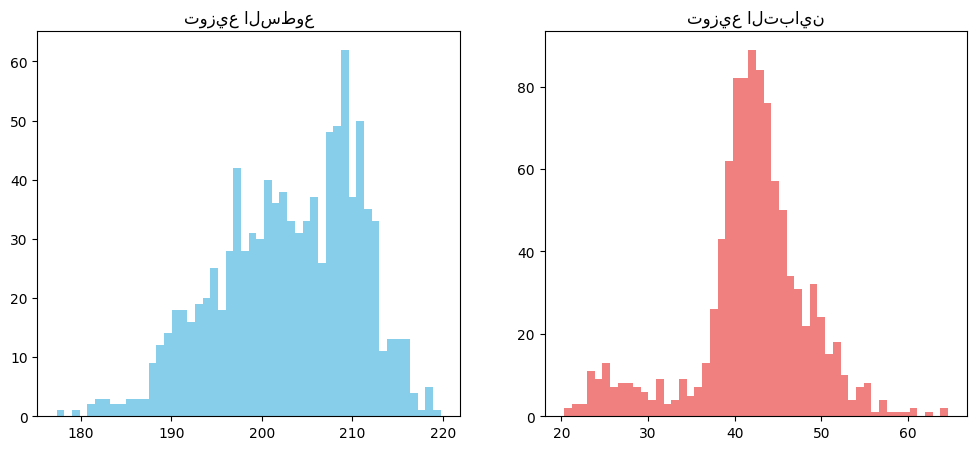

In [6]:
def analyze_image_quality(dataset_path, sample_size=1000):
    all_images = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))
    
    if not all_images:
        print("لم يتم العثور على صور في المسار المحدد.")
        return
        
    # استخدام np.random.choice لضمان عدم تكرار الصور في العينة
    sample_images = np.random.choice(all_images, min(sample_size, len(all_images)), replace=False)
    
    brightness_list = []
    contrast_list = []
    
    for img_path in sample_images:
        img = cv2.imread(img_path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness_list.append(np.mean(gray))
            contrast_list.append(np.std(gray))
            
    print(f"متوسط السطوع: {np.mean(brightness_list):.2f}")
    print(f"متوسط التباين: {np.mean(contrast_list):.2f}")
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(brightness_list, bins=50, color='skyblue')
    plt.title('توزيع السطوع')
    plt.subplot(1, 2, 2)
    plt.hist(contrast_list, bins=50, color='lightcoral')
    plt.title('توزيع التباين')
    plt.show()

analyze_image_quality(DATASET_PATH)


## 🧩 الخطوة 2: المعالجة المسبقة الفعالة (Efficient Preprocessing)
**تطبيق النصيحة الحرجة:** تجنب المعالجة المسبقة في مكانها (Resize, Normalize, Grayscale) على القرص. نستخدم `ImageDataGenerator` لتطبيق جميع التغييرات في الذاكرة (On-the-fly) والعمل على صور **RGB (3 قنوات)**.### الخلية 4: إعداد مولدات البيانات (Generators)


In [7]:
# مولد بيانات التدريب: يتضمن التعزيز والتطبيع
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # التطبيع إلى [0, 1]
    rotation_range=25,              # تدوير ±25 درجة
    horizontal_flip=True,           # عكس أفقي
    brightness_range=[0.7, 1.3],    # سطوع عشوائي
    shear_range=0.2,                # قص عشوائي
    zoom_range=0.2,                 # تكبير/تصغير عشوائي
    fill_mode='nearest'             # ملء البكسلات المفقودة
)

# مولد بيانات التحقق والاختبار: يتضمن التطبيع فقط
val_test_datagen = ImageDataGenerator(rescale=1./255)

# تحديد مسارات المجلدات
train_path = os.path.join(DATASET_PATH, "Train")
val_path = os.path.join(DATASET_PATH, "Validate")
test_path = os.path.join(DATASET_PATH, "Test")

# تحميل البيانات باستخدام المولدات
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb' # **هام: استخدام RGB لـ EfficientNetB3**
)

validation_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False # لا حاجة للخلط في بيانات الاختبار
)

print("تم إعداد مولدات البيانات بنجاح.")


Found 21234 images belonging to 11 classes.
Found 2650 images belonging to 11 classes.
Found 2650 images belonging to 11 classes.
تم إعداد مولدات البيانات بنجاح.


## 🧠 الخطوة 3: بناء نموذج التصنيف (EfficientNetB3 Classifier)
### الخلية 5: بناء النموذج باستخدام التعلم بالنقل (Transfer Learning)


In [8]:
# بناء النموذج باستخدام Transfer Learning
base_model = EfficientNetB3(
    weights='imagenet',      # استخدام أوزان ImageNet
    include_top=False,       # إزالة الطبقة العلوية
    input_shape=IMAGE_SIZE + (3,) # حجم الصورة (224, 224, 3)
)

# تجميد الطبقات الأساسية (للتدريب الأولي)
base_model.trainable = False

# إضافة الطبقات العلوية الجديدة
x = GlobalAveragePooling2D()(base_model.output)
output = Dense(NUM_CLASSES, activation='softmax')(x)  # 11 فئة لخلايا الدم

# إنشاء النموذج النهائي
model = Model(inputs=base_model.input, outputs=output)

# تجميع النموذج
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("تم إنشاء النموذج بنجاح.")
model.summary()


تم إنشاء النموذج بنجاح.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 10,800,442 (41.20 MB)

 Trainable params: 16,907 (66.04 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

## 🎯 الخطوة 4: تدريب النموذج (Model Training)
### الخلية 6: إعداد Callbacks وبدء التدريب
**تطبيق النصيحة:** استخدام `EarlyStopping` و `ModelCheckpoint` لضمان أفضل أداء وتجنب الإفراط في الملاءمة (Overfitting).


In [11]:
# إعداد Callbacks
checkpoint = ModelCheckpoint(
    'best_efficientnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5, # التوقف المبكر بعد 5 دورات دون تحسن
    restore_best_weights=True,
    verbose=1
)

# بدء التدريب
history = model.fit(
    train_generator,
    epochs=1, # يمكن زيادتها أو تقليلها حسب الحاجة
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping]
)

print("اكتمل التدريب الأولي لنموذج EfficientNetB3.")


664/664 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1303 - loss: 2.3229
Epoch 1: val_accuracy improved from None to 0.19962, saving model to best_efficientnet_model.h5


664/664 ━━━━━━━━━━━━━━━━━━━━ 1341s 2s/step - accuracy: 0.1400 - loss: 2.3081 - val_accuracy: 0.1996 - val_loss: 2.2556
Restoring model weights from the end of the best epoch: 1.
اكتمل التدريب الأولي لنموذج EfficientNetB3.


## 🧪 الخطوة 5: تقييم الأداء والتحقق من النموذج (Evaluation & Validation)
### الخلية 7: تقييم الأداء على مجموعة الاختبار


83/83 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.1985 - loss: 2.2616
دقة النموذج على مجموعة الاختبار: 19.85%


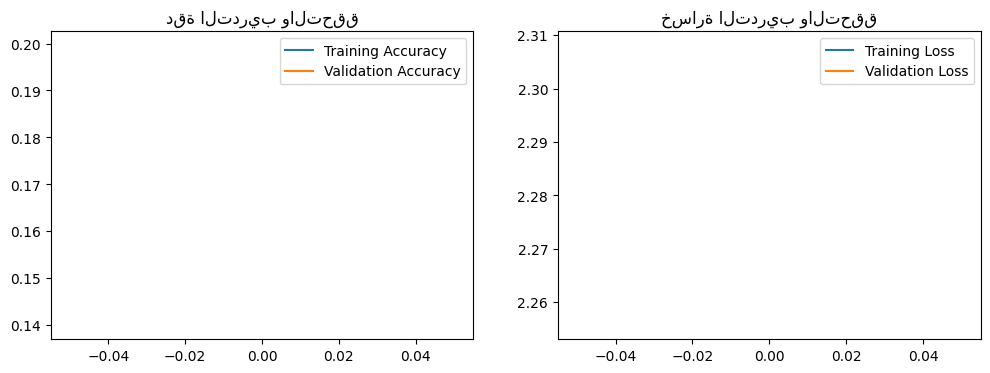

In [12]:
# تحميل أفضل نموذج تم حفظه
model.load_weights('best_efficientnet_model.h5')

# تقييم النموذج على بيانات الاختبار
loss, accuracy = model.evaluate(test_generator)
print(f"دقة النموذج على مجموعة الاختبار: {accuracy*100:.2f}%")

# عرض منحنيات التدريب
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('دقة التدريب والتحقق')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('خسارة التدريب والتحقق')
plt.legend()
plt.show()


## 🧠 الخطوة 6: بناء نموذج العدّ (YOLOv8 Detector) - (إطار عمل)
**ملاحظة:** بما أن تدريب YOLOv8 يتطلب بيئة مختلفة (مثل Ultralytics) وبيانات مُعلّمة (Labeled Data)، فإن هذه الخلية توفر إطار العمل النظري لدمج النموذج المدرب مسبقاً.
### الخلية 8: إطار عمل YOLOv8


In [13]:
# **افتراض:** تم تدريب نموذج YOLOv8 وحفظه في المسار التالي
YOLOV8_MODEL_PATH = "/home/ubuntu/models/yolov8n_wbc_detector.pt"

# **ملاحظة:** يتطلب هذا تثبيت مكتبة ultralytics
# from ultralytics import YOLO
# detector = YOLO(YOLOV8_MODEL_PATH)

print("تم تحديد مسار نموذج YOLOv8.")
print("الخطوة التالية هي استخدام هذا النموذج للكشف عن الخلايا.")


تم تحديد مسار نموذج YOLOv8.
الخطوة التالية هي استخدام هذا النموذج للكشف عن الخلايا.


## 🔁 الخطوة 7: دمج النماذج (Integration) - (إطار عمل)
**الهدف:** ربط مخرجات YOLOv8 (مواقع الخلايا) بمدخلات EfficientNetB3 (تصنيف الخلايا المقصوصة).
### الخلية 9: دالة الدمج (Integration Function)


In [14]:
def integrate_models(image_path, classification_model, detection_model):
    """
    دالة دمج YOLOv8 (للكشف) مع EfficientNetB3 (للتصنيف).
    """
    # 1. الكشف باستخدام YOLOv8
    # results = detection_model(image_path)
    # detections = results[0].boxes.xyxy.cpu().numpy() # إحداثيات الخلايا المكتشفة
    
    # **محاكاة لنتائج الكشف (للتجربة)**
    detections = np.array([[50, 50, 150, 150], [200, 200, 300, 300]])
    
    # 2. تحميل الصورة الأصلية
    img = cv2.imread(image_path)
    if img is None: return {}
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    classification_results = {}
    
    # 3. قص وتصنيف كل خلية مكتشفة
    for i, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box)
        cropped_cell = img[y1:y2, x1:x2]
        
        # 4. المعالجة المسبقة للتصنيف
        resized_cell = cv2.resize(cropped_cell, IMAGE_SIZE)
        normalized_cell = resized_cell / 255.0
        input_tensor = np.expand_dims(normalized_cell, axis=0)
        
        # 5. التصنيف باستخدام EfficientNetB3
        # prediction = classification_model.predict(input_tensor)
        # predicted_class_index = np.argmax(prediction)
        # predicted_class = train_generator.class_indices # يجب استخدام خريطة الفئات الفعلية
        # **محاكاة لاسم الفئة**
        predicted_class_name = f"Class_{i}"
        
        # 6. تجميع النتائج
        classification_results[predicted_class_name] = classification_results.get(predicted_class_name, 0) + 1
        
    return classification_results

print("تم تعريف دالة الدمج بنجاح.")


تم تعريف دالة الدمج بنجاح.
